In [1]:
import seaborn as sns
import pandas as pd

# Load the dataset
df = sns.load_dataset("diamonds")

# Quick inspection
print("--- INFO ---")
df.info()

print("\n--- DESCRIBE ---")
print(df.describe())

--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB

--- DESCRIBE ---
              carat         depth         table         price             x  \
count  53940.000000  53940.000000  53940.000000  53940.000000  53940.000000   
mean       0.797940     61.749405     57.457184   3932.799722      5.731157   
std        0.474011      1.432621      2.234491   3989.439738      1.121761   
min        0.

unico limite, rimuovere solo gli outlier oltre 3 deviazioni standard

Controllo valori nulli


In [2]:
# Conta dei valori mancanti per colonna
print(df.isnull().sum() / len(df) * 100)

carat      0.0
cut        0.0
color      0.0
clarity    0.0
depth      0.0
table      0.0
price      0.0
x          0.0
y          0.0
z          0.0
dtype: float64


 "Quattro C" (Caratteristiche principali)
carat (numerica): Il peso del diamante (da 0.2 a 5.01).
cut (ordinale): Qualità del taglio (Fair, Good, Very Good, Premium, Ideal).
color (ordinale): Colore del diamante, dal peggiore (J) al migliore (D).
clarity (ordinale): Misura della purezza (I1 (peggiore), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (migliore)). 
Kaggle
Kaggle
Dimensioni e Misurazioni Fisiche
depth (numerica): Percentuale di profondità totale = 
.
table (numerica): Larghezza della parte superiore del diamante rispetto al punto più largo.
x (numerica): Lunghezza in mm.
y (numerica): Larghezza in mm.
z (numerica): Profondità in mm. 
Kaggle
Kaggle
Prezzo
price (intera): Prezzo in dollari USA ($326--$18,823).

# Rimozione Outliers


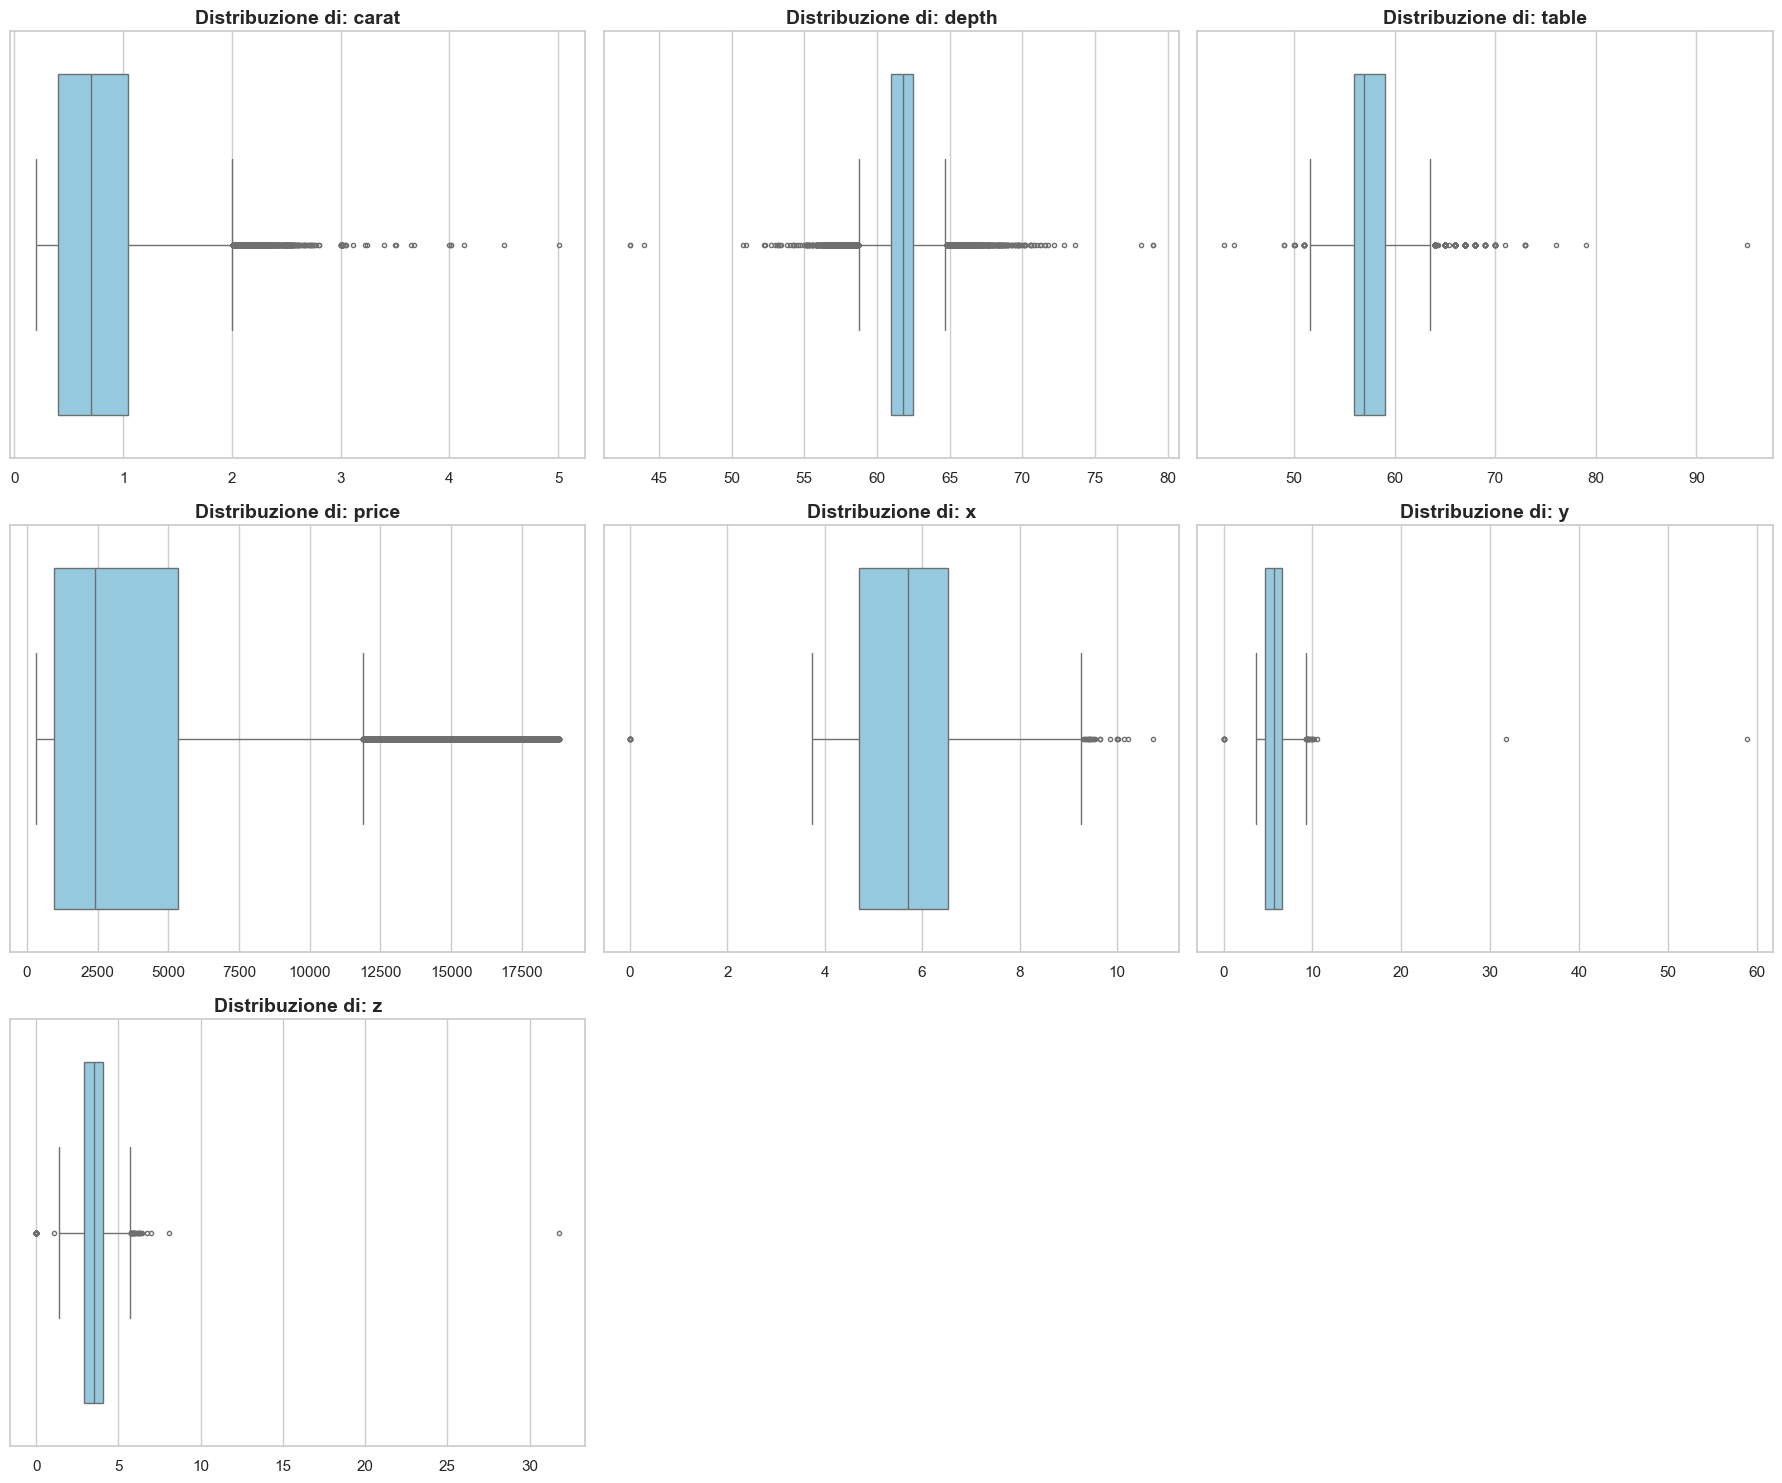

In [3]:
import matplotlib.pyplot as plt
# Impostiamo lo stile e la griglia

sns.set_theme(style="whitegrid")

# Creiamo figura 3x3
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten()

# Ciclo per creare boxplot solo per colonne numeriche
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='skyblue', fliersize=3)
    axes[i].set_title(f'Distribuzione di: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')

# Rimuovo eventuali assi vuoti (se ci sono più subplot che colonne)
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

# Ottimizzazione layout
plt.tight_layout()
plt.show()

In [4]:
import numpy as np
from scipy import stats

def remove_outliers_zscore(data, columns, threshold=3):
    df_clean = data.copy()
    # Calcoliamo lo Z-score assoluto per ogni colonna selezionata
    z_scores = np.abs(stats.zscore(df_clean[columns]))

    # Teniamo solo le righe dove TUTTE le colonne hanno Z < threshold
    filtered_entries = (z_scores < threshold).all(axis=1)
    return df_clean[filtered_entries]

# Applicazione
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

df_encoded = remove_outliers_zscore(df, numeric_cols)
print(f"Righe rimosse con Z-Score: {len(df) - len(df_encoded)}")
df = df_encoded

Righe rimosse con Z-Score: 2350


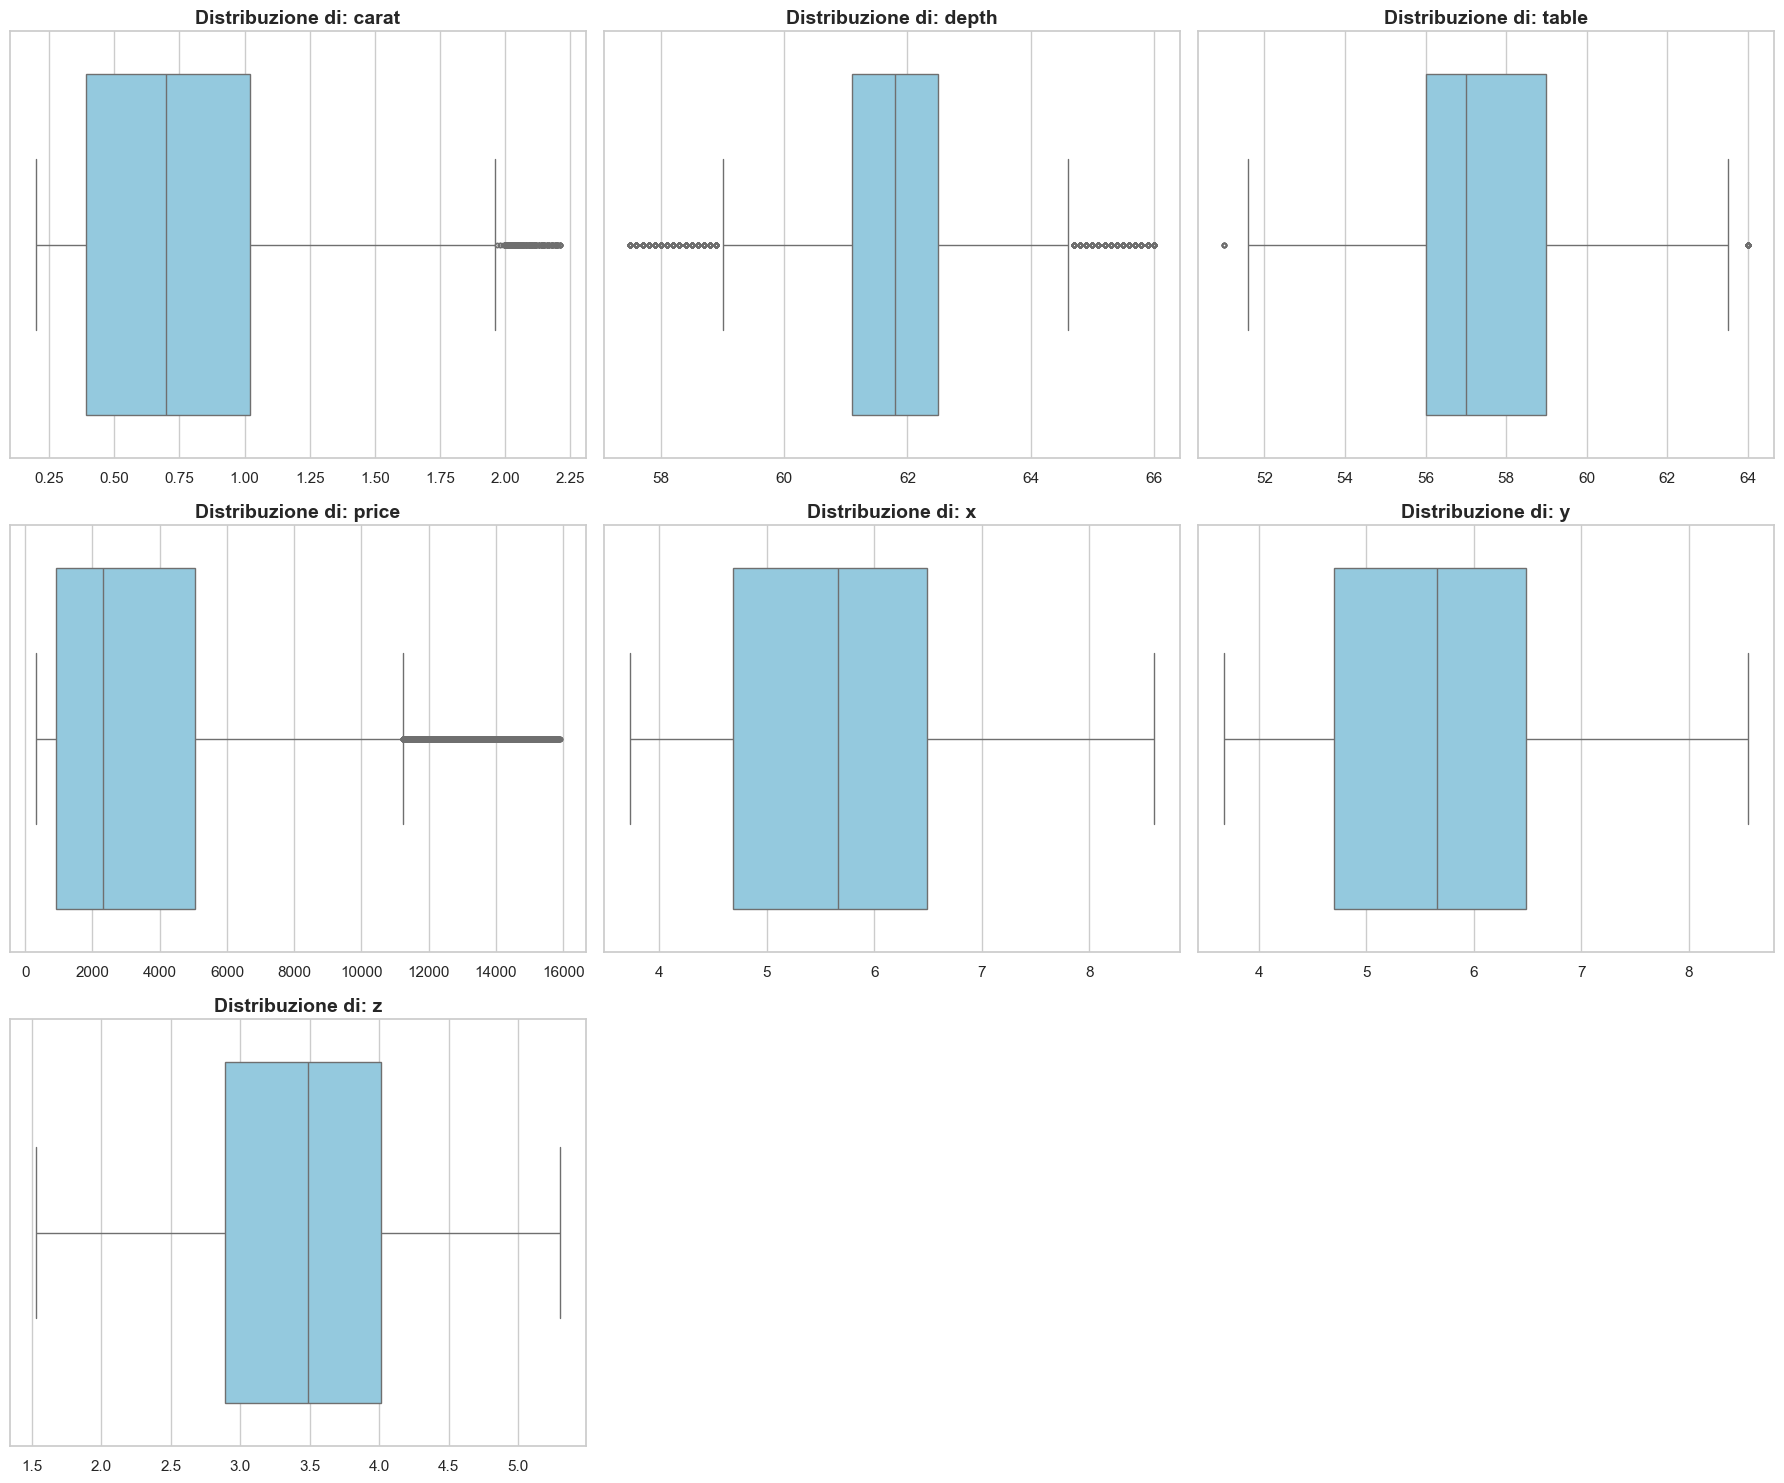

In [5]:
import matplotlib.pyplot as plt
# Impostiamo lo stile e la griglia

sns.set_theme(style="whitegrid")

# Creiamo figura 3x3
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten()

# Ciclo per creare boxplot solo per colonne numeriche
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df[col], ax=axes[i], color='skyblue', fliersize=3)
    axes[i].set_title(f'Distribuzione di: {col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('')

# Rimuovo eventuali assi vuoti (se ci sono più subplot che colonne)
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

# Ottimizzazione layout
plt.tight_layout()
plt.show()

# Feature Engineering


In [6]:
# Creazione della feature Volume
df['volume'] = df['x'] * df['y'] * df['z']

#Check dei dimanti con volume 0
print(f"Diamanti con volume zero: {(df['volume'] == 0).sum()}")

Diamanti con volume zero: 0


In [7]:
#Rapporto Lunghezza/Larghezza (L/W Ratio)
#Indica quanto il diamante è "allungato" rispetto a quanto è "rotondo". Per un diamante tondo ideale, il rapporto è 1.

df['l_w_ratio'] = df['x'] / df['y']

In [8]:
# Poiché il diamante è composto da carbonio puro, la relazione tra peso (carat) e volume dovrebbe essere costante. 
# Anomalie in questo rapporto potrebbero indicare errori nei dati o tagli molto particolari.
df['carat_per_volume'] = df['carat'] / df['volume']

## XGBoost 


--- RISULTATI XGBOOST ---
MSE: 188945.72
RMSE: 434.68 $


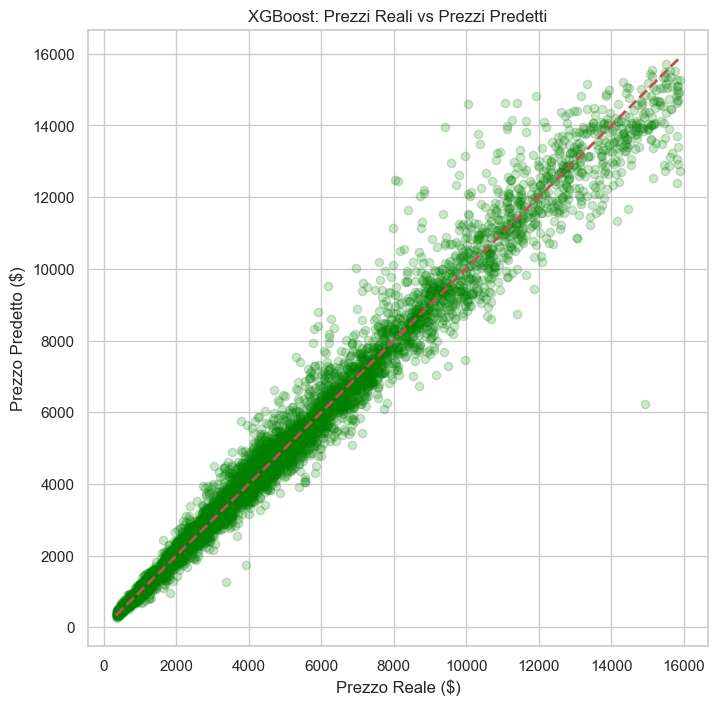

In [9]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

X = df.drop("price", axis=1)
y = df["price"]

# 3. Convertiamo le colonne categoriche in tipo "category"
categorical_cols = ["cut", "color", "clarity"]
for col in categorical_cols:
    X[col] = X[col].astype("category")

# 4. Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Inizializzazione modello con supporto categoriche
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1,
    enable_categorical=True,   # fondamentale
    tree_method="hist"         # richiesto per categorical
)

# 6. Training
xgb_model.fit(X_train, y_train)

# 7. Predizione
y_pred_xgb = xgb_model.predict(X_test)

# 8. Metriche
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)

print(f"--- RISULTATI XGBOOST ---")
print(f"MSE: {mse_xgb:.2f}")
print(f"RMSE: {rmse_xgb:.2f} $")

# 9. Grafico
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_xgb, alpha=0.2, color='green')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)

plt.title('XGBoost: Prezzi Reali vs Prezzi Predetti')
plt.xlabel('Prezzo Reale ($)')
plt.ylabel('Prezzo Predetto ($)')
plt.show()

# Xgboost con Optuna

[I 2026-03-04 13:55:20,466] A new study created in memory with name: no-name-cee95ad1-cdc1-4c89-9cec-cb94bc60183a
[I 2026-03-04 13:55:27,035] Trial 0 finished with value: 598.6802775065104 and parameters: {'n_estimators': 805, 'max_depth': 9, 'learning_rate': 0.23878473889854926, 'subsample': 0.8996966382358429, 'colsample_bytree': 0.6918567552280012, 'min_child_weight': 6, 'gamma': 1.4401121179173608, 'reg_alpha': 4.25163694902015, 'reg_lambda': 2.9270544558162905}. Best is trial 0 with value: 598.6802775065104.
[I 2026-03-04 13:55:31,048] Trial 1 finished with value: 548.2660725911459 and parameters: {'n_estimators': 310, 'max_depth': 10, 'learning_rate': 0.04737885196433884, 'subsample': 0.9800745599868532, 'colsample_bytree': 0.9447377654040793, 'min_child_weight': 2, 'gamma': 2.6260619795530493, 'reg_alpha': 1.2696961598362966, 'reg_lambda': 3.942353986715663}. Best is trial 1 with value: 548.2660725911459.
[I 2026-03-04 13:55:33,791] Trial 2 finished with value: 567.1062418619791

Best trial:
{'n_estimators': 904, 'max_depth': 7, 'learning_rate': 0.01070958394684227, 'subsample': 0.6324937740050179, 'colsample_bytree': 0.9677327689951137, 'min_child_weight': 5, 'gamma': 1.5552350222672522, 'reg_alpha': 2.564938890712226, 'reg_lambda': 0.9560180083090861}

--- RISULTATI FINALI DOPO TUNING ---
MSE: 276650.72
RMSE: 525.98 $


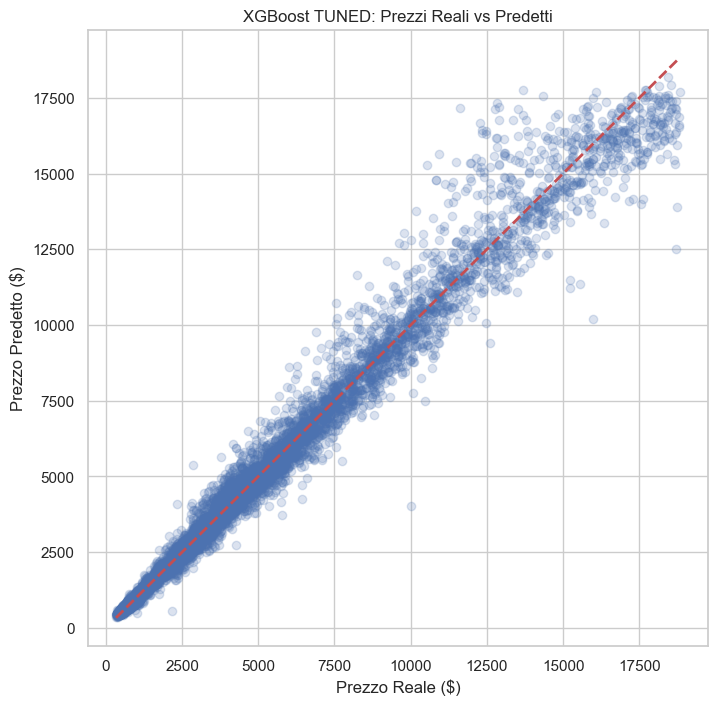

In [11]:
import seaborn as sns
import pandas as pd
import numpy as np
import optuna
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor

# 1. Load dataset
df = sns.load_dataset("diamonds")

X = df.drop("price", axis=1)
y = df["price"]

# 2. Convert categorical columns
categorical_cols = ["cut", "color", "clarity"]
for col in categorical_cols:
    X[col] = X[col].astype("category")

# 3. Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------
# 4. OPTUNA OBJECTIVE
# -------------------------

def objective(trial):
    
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
        "random_state": 42,
        "n_jobs": -1,
        "enable_categorical": True,
        "tree_method": "hist"
    }
    
    model = XGBRegressor(**params)
    
    # Cross-validation 3-fold
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=3,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    
    return -scores.mean()  # minimizziamo RMSE

# -------------------------
# 5. RUN OPTUNA
# -------------------------

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print("Best trial:")
print(study.best_trial.params)

# -------------------------
# 6. TRAIN BEST MODEL
# -------------------------

best_model = XGBRegressor(
    **study.best_trial.params,
    random_state=42,
    n_jobs=-1,
    enable_categorical=True,
    tree_method="hist"
)

best_model.fit(X_train, y_train)

# -------------------------
# 7. FINAL EVALUATION
# -------------------------

y_pred = best_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\n--- RISULTATI FINALI DOPO TUNING ---")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f} $")

# Plot
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.2)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2)

plt.title('XGBoost TUNED: Prezzi Reali vs Predetti')
plt.xlabel('Prezzo Reale ($)')
plt.ylabel('Prezzo Predetto ($)')
plt.show()